# Customer Churn Prediction: Phase 6: Evaluation & Feature Importance


## 0. Setup


In [1]:
import pandas as pd
import numpy as np
import pickle
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_curve, auc, RocCurveDisplay
)

COLORS = {
    'no_churn' : '#2C6E91',
    'churn'    : '#E53935',
    'neutral'  : '#F4A259',
    'green'    : '#4CAF50',
    'bg'       : '#F7F9FC',
}
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams.update({'figure.facecolor': COLORS['bg'], 'axes.facecolor': COLORS['bg']})

# Load everything from Phase 5
with open('../models/trained_models.pkl', 'rb') as f:
    m = pickle.load(f)

lr_model  = m['logistic_regression']['model']
rf_model  = m['random_forest']['model']
xgb_model = m['xgboost']['model']

lr_pred   = m['logistic_regression']['pred']
rf_pred   = m['random_forest']['pred']
xgb_pred  = m['xgboost']['pred']

lr_prob   = m['logistic_regression']['pred_prob']
rf_prob   = m['random_forest']['pred_prob']
xgb_prob  = m['xgboost']['pred_prob']

y_test        = m['y_test']
X_test        = m['X_test']
feature_names = m['feature_names']
results_df    = m['results_df']

print('Models and predictions loaded.')
print(f'Test samples: {len(y_test):,}  |  Actual churners: {y_test.sum():,} ({y_test.mean()*100:.1f}%)')

Models and predictions loaded.
Test samples: 1,409  |  Actual churners: 374 (26.5%)


## Chart 1: Confusion Matrices


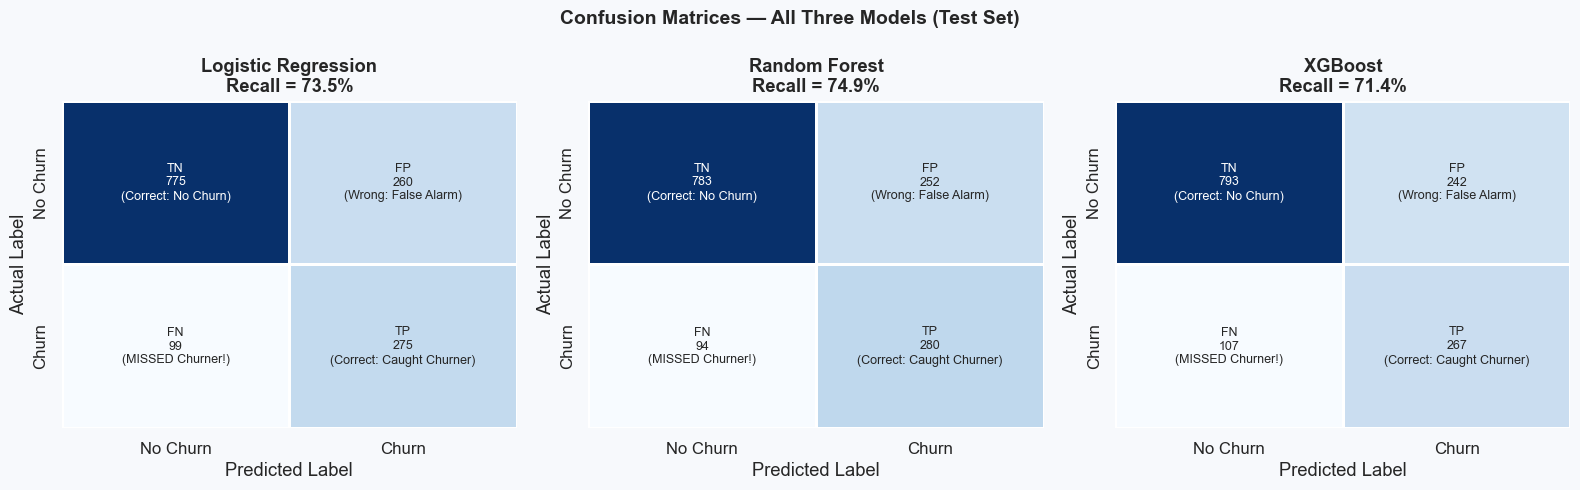

Chart saved: docs/charts/09_confusion_matrices.png


In [2]:
model_names = ['Logistic Regression', 'Random Forest', 'XGBoost']
preds       = [lr_pred, rf_pred, xgb_pred]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Confusion Matrices — All Three Models (Test Set)', fontsize=14, fontweight='bold')

for ax, name, pred in zip(axes, model_names, preds):
    cm = confusion_matrix(y_test, pred)
    tn, fp, fn, tp = cm.ravel()

    # Custom annotation with labels so it's instantly readable
    labels = np.array([
        [f'TN\n{tn:,}\n(Correct: No Churn)', f'FP\n{fp:,}\n(Wrong: False Alarm)'],
        [f'FN\n{fn:,}\n(MISSED Churner!)',   f'TP\n{tp:,}\n(Correct: Caught Churner)']
    ])

    # Color: green for correct (TN, TP), red for errors (FP, FN)
    cell_colors = np.array([[COLORS['green'], COLORS['neutral']],
                             [COLORS['churn'], COLORS['green']]])

    for i in range(2):
        for j in range(2):
            ax.add_patch(plt.Rectangle((j-0.5, i-0.5), 1, 1,
                                        color=cell_colors[i,j], alpha=0.25))

    sns.heatmap(cm, annot=labels, fmt='', ax=ax,
                cmap='Blues', linewidths=2, linecolor='white',
                xticklabels=['No Churn', 'Churn'],
                yticklabels=['No Churn', 'Churn'],
                annot_kws={'size': 9},
                cbar=False)

    recall_val = tp / (tp + fn) * 100
    ax.set_title(f'{name}\nRecall = {recall_val:.1f}%', fontweight='bold')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('Actual Label')

plt.tight_layout()
plt.savefig('../docs/charts/09_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved: docs/charts/09_confusion_matrices.png')

## Chart 2: ROC-AUC Curves


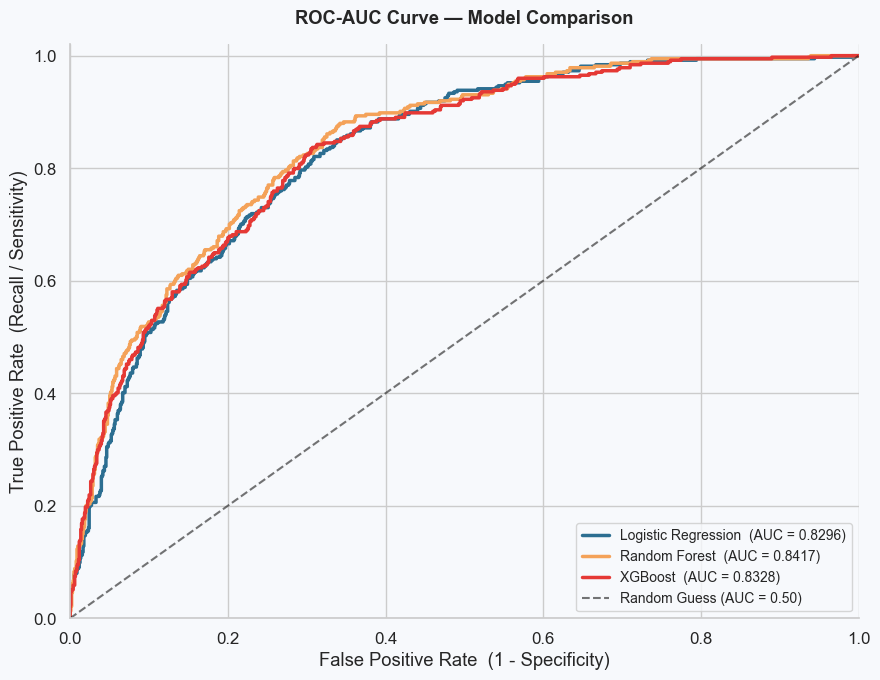

AUC Scores:
  Random Forest             AUC = 0.8417
  XGBoost                   AUC = 0.8328
  Logistic Regression       AUC = 0.8296


In [3]:
fig, ax = plt.subplots(figsize=(9, 7))

model_probs = [
    (lr_prob,  'Logistic Regression', COLORS['no_churn']),
    (rf_prob,  'Random Forest',       COLORS['neutral']),
    (xgb_prob, 'XGBoost',             COLORS['churn']),
]

auc_scores = {}
for prob, name, color in model_probs:
    fpr, tpr, _ = roc_curve(y_test, prob)
    roc_auc     = auc(fpr, tpr)
    auc_scores[name] = roc_auc
    ax.plot(fpr, tpr, color=color, linewidth=2.5,
            label=f'{name}  (AUC = {roc_auc:.4f})')

# Diagonal = random guessing baseline
ax.plot([0,1],[0,1], 'k--', linewidth=1.5, alpha=0.6, label='Random Guess (AUC = 0.50)')
ax.fill_between([0,1],[0,1],[0,1], alpha=0.04, color='grey')

ax.set_title('ROC-AUC Curve — Model Comparison', pad=15, fontweight='bold')
ax.set_xlabel('False Positive Rate  (1 - Specificity)')
ax.set_ylabel('True Positive Rate  (Recall / Sensitivity)')
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('../docs/charts/10_roc_auc.png', dpi=150, bbox_inches='tight')
plt.show()

print('AUC Scores:')
for name, score in sorted(auc_scores.items(), key=lambda x: -x[1]):
    print(f'  {name:<25} AUC = {score:.4f}')

## Chart 3: Classification Reports


In [4]:
for name, pred in zip(model_names, preds):
    print(f'\n{name}')
    print(classification_report(
        y_test, pred,
        target_names=['No Churn (0)', 'Churn (1)'],
        digits=3
    ))



Logistic Regression
              precision    recall  f1-score   support

No Churn (0)      0.887     0.749     0.812      1035
   Churn (1)      0.514     0.735     0.605       374

    accuracy                          0.745      1409
   macro avg      0.700     0.742     0.709      1409
weighted avg      0.788     0.745     0.757      1409


Random Forest
              precision    recall  f1-score   support

No Churn (0)      0.893     0.757     0.819      1035
   Churn (1)      0.526     0.749     0.618       374

    accuracy                          0.754      1409
   macro avg      0.710     0.753     0.719      1409
weighted avg      0.796     0.754     0.766      1409


XGBoost
              precision    recall  f1-score   support

No Churn (0)      0.881     0.766     0.820      1035
   Churn (1)      0.525     0.714     0.605       374

    accuracy                          0.752      1409
   macro avg      0.703     0.740     0.712      1409
weighted avg      0.786     0

## Best Model Selection


In [5]:
from sklearn.metrics import recall_score, f1_score

summary = pd.DataFrame({
    'Model'    : model_names,
    'Recall'   : [recall_score(y_test, p) for p in preds],
    'AUC'      : [auc_scores[n] for n in model_names],
    'F1'       : [f1_score(y_test, p) for p in preds],
}).round(4)

print('Final Model Selection Scorecard:')
print(summary.to_string(index=False))
print()

# Pick best by Recall
best_idx   = summary['Recall'].idxmax()
best_name  = summary.loc[best_idx, 'Model']
best_recall = summary.loc[best_idx, 'Recall']
best_auc   = summary.loc[best_idx, 'AUC']

print(f'Selected Model : {best_name}')
print(f'Reason         : Highest Recall ({best_recall*100:.1f}%) — catches the most churners')
print(f'AUC            : {best_auc:.4f}')

Final Model Selection Scorecard:
              Model  Recall    AUC     F1
Logistic Regression  0.7353 0.8296 0.6051
      Random Forest  0.7487 0.8417 0.6181
            XGBoost  0.7139 0.8328 0.6048

Selected Model : Random Forest
Reason         : Highest Recall (74.9%) — catches the most churners
AUC            : 0.8417


## Chart 4: Feature Importance


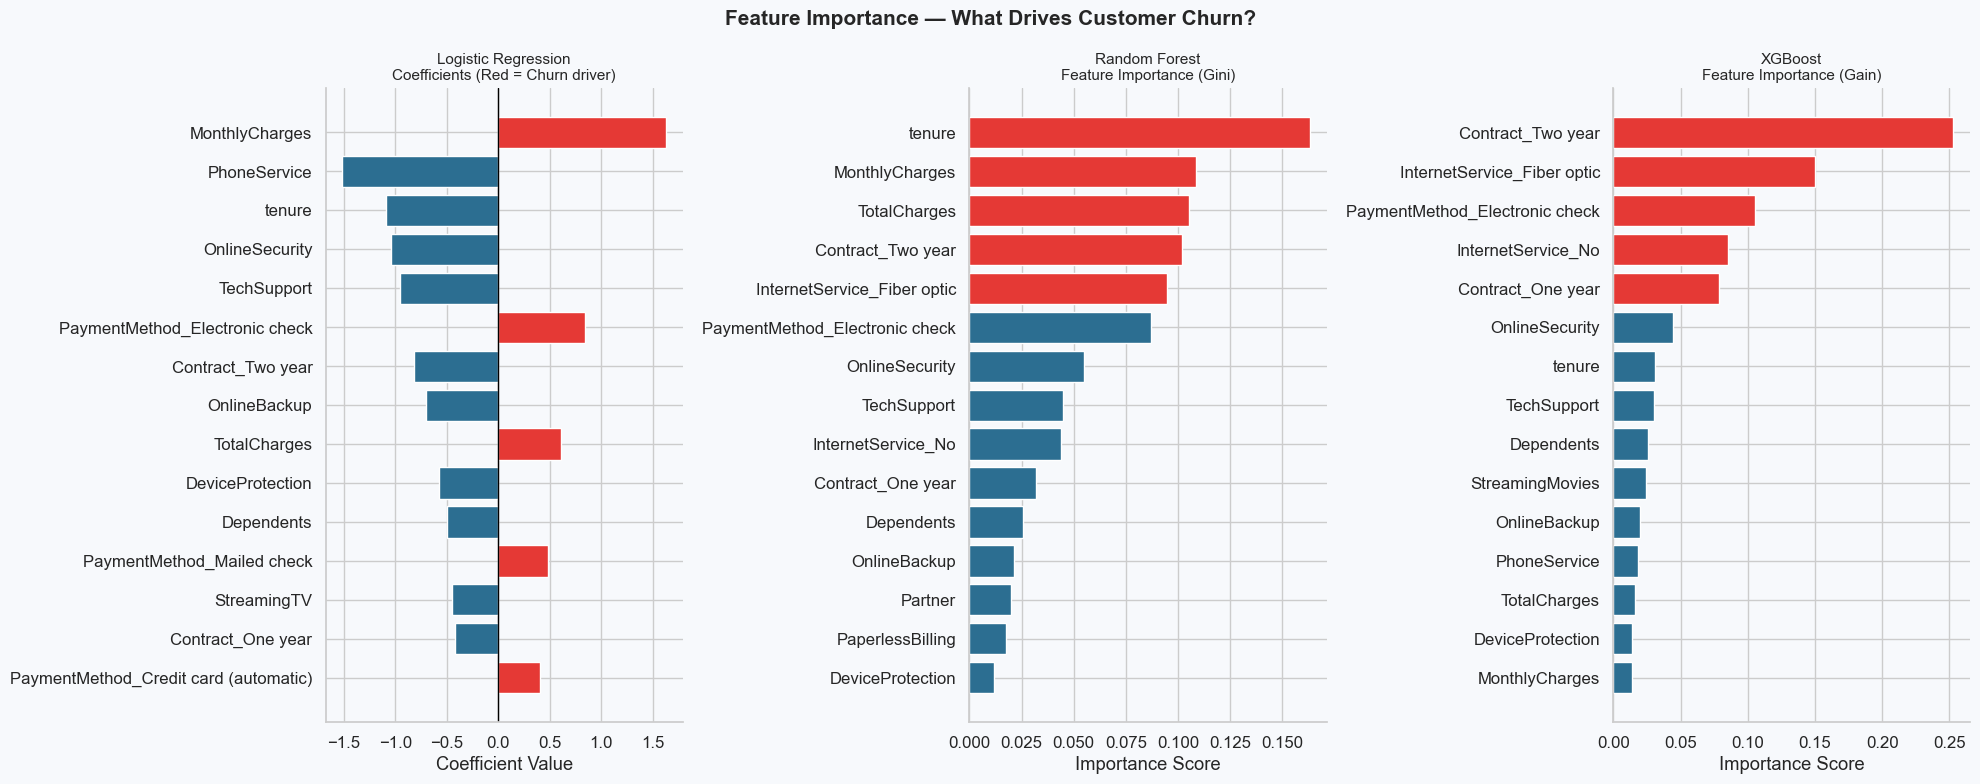

Chart saved: docs/charts/11_feature_importance.png


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(20, 8))
fig.suptitle('Feature Importance — What Drives Customer Churn?',
             fontsize=15, fontweight='bold')

# Logistic Regression Coefficients 
# Coefficient = weight assigned to each feature.
# Positive = pushes toward Churn=1, Negative = pushes toward No Churn.
# We exponentiate to get Odds Ratios — more interpretable.
lr_coef = pd.DataFrame({
    'Feature'    : feature_names,
    'Coefficient': lr_model.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False).head(15)

colors_lr = [COLORS['churn'] if c > 0 else COLORS['no_churn']
             for c in lr_coef['Coefficient']]
axes[0].barh(lr_coef['Feature'][::-1], lr_coef['Coefficient'][::-1],
             color=colors_lr[::-1], edgecolor='white')
axes[0].axvline(0, color='black', linewidth=1)
axes[0].set_title('Logistic Regression\nCoefficients (Red = Churn driver)', fontsize=11)
axes[0].set_xlabel('Coefficient Value')

# Random Forest Importances 
rf_imp = pd.DataFrame({
    'Feature'   : feature_names,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

bar_colors_rf = [COLORS['churn'] if i < 5 else COLORS['no_churn']
                 for i in range(len(rf_imp))]
axes[1].barh(rf_imp['Feature'][::-1], rf_imp['Importance'][::-1],
             color=bar_colors_rf[::-1], edgecolor='white')
axes[1].set_title('Random Forest\nFeature Importance (Gini)', fontsize=11)
axes[1].set_xlabel('Importance Score')

# XGBoost Importances 
xgb_imp = pd.DataFrame({
    'Feature'   : feature_names,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

bar_colors_xgb = [COLORS['churn'] if i < 5 else COLORS['no_churn']
                  for i in range(len(xgb_imp))]
axes[2].barh(xgb_imp['Feature'][::-1], xgb_imp['Importance'][::-1],
             color=bar_colors_xgb[::-1], edgecolor='white')
axes[2].set_title('XGBoost\nFeature Importance (Gain)', fontsize=11)
axes[2].set_xlabel('Importance Score')

for ax in axes:
    ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('../docs/charts/11_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved: docs/charts/11_feature_importance.png')

## Feature Importance: Top 10 with Business Labels


In [7]:
# Combine RF and XGB importances — average rank across both tree models
rf_ranks  = rf_imp.reset_index(drop=True).reset_index().rename(columns={'index':'RF_rank'})
xgb_ranks = xgb_imp.reset_index(drop=True).reset_index().rename(columns={'index':'XGB_rank'})

combined = pd.merge(rf_ranks[['Feature','RF_rank','Importance']],
                    xgb_ranks[['Feature','XGB_rank']],
                    on='Feature', how='outer').fillna(14)
combined['AvgRank'] = (combined['RF_rank'] + combined['XGB_rank']) / 2
combined = combined.sort_values('AvgRank').head(10)

print('TOP 10 CHURN DRIVERS (consensus across RF + XGBoost):')
for i, row in combined.reset_index(drop=True).iterrows():
    print(f'{i+1:2}. {row["Feature"]:<35}  RF Rank #{int(row["RF_rank"])+1}')
print()
print('Business Translation:')
print('  tenure          → How long customer has been with us (longer = loyal)')
print('  MonthlyCharges  → Higher monthly bill = more likely to shop around')
print('  Contract_*      → Month-to-month = no switching cost = easy to leave')
print('  InternetService → Fiber optic users have highest expectations')
print('  TechSupport     → No support = frustration = churn')
print('  PaymentMethod   → Electronic check correlates with disengaged customers')

TOP 10 CHURN DRIVERS (consensus across RF + XGBoost):
 1. Contract_Two year                    RF Rank #4
 2. InternetService_Fiber optic          RF Rank #5
 3. tenure                               RF Rank #1
 4. PaymentMethod_Electronic check       RF Rank #6
 5. OnlineSecurity                       RF Rank #7
 6. InternetService_No                   RF Rank #9
 7. Contract_One year                    RF Rank #10
 8. TotalCharges                         RF Rank #3
 9. TechSupport                          RF Rank #8
10. MonthlyCharges                       RF Rank #2

Business Translation:
  tenure          → How long customer has been with us (longer = loyal)
  MonthlyCharges  → Higher monthly bill = more likely to shop around
  Contract_*      → Month-to-month = no switching cost = easy to leave
  InternetService → Fiber optic users have highest expectations
  TechSupport     → No support = frustration = churn
  PaymentMethod   → Electronic check correlates with disengaged customers

## Financial Impact Calculation


In [8]:
# Use best model predictions
preds_dict = {
    'Logistic Regression': lr_pred,
    'Random Forest'      : rf_pred,
    'XGBoost'            : xgb_pred
}
best_pred = preds_dict[best_name]

# Business assumptions
avg_monthly_revenue_per_customer = 65.0   # avg MonthlyCharges
total_customers                  = 7043
churn_rate                       = 0.265  # 26.5% from EDA
monthly_churners                 = int(total_customers * churn_rate)

# Model performance on test set
from sklearn.metrics import confusion_matrix, recall_score
cm      = confusion_matrix(y_test, best_pred)
tn, fp, fn, tp = cm.ravel()
recall  = tp / (tp + fn)

# Scale from test set to full customer base
test_ratio          = len(y_test) / total_customers
est_churners_caught = int(monthly_churners * recall)
retention_rate      = 0.30   # assume 30% of contacted churners are saved by campaign
customers_saved     = int(est_churners_caught * retention_rate)
monthly_saved       = customers_saved * avg_monthly_revenue_per_customer
annual_saved        = monthly_saved * 12

# Campaign cost
promo_cost_per_contact = 10.0   # $10 promo code or call
campaign_cost          = est_churners_caught * promo_cost_per_contact
net_benefit_monthly    = monthly_saved - campaign_cost

print(' FINANCIAL IMPACT ANALYSIS')
print(f' Best Model              : {best_name}')
print(f' Recall on Churn class   : {recall*100:.1f}%')
print()
print(f' Total customers         : {total_customers:,}')
print(f' Est. monthly churners   : {monthly_churners:,} ({churn_rate*100:.0f}% churn rate)')
print(f' Churners model catches  : {est_churners_caught:,} ({recall*100:.0f}% recall)')
print()
print(f' Retention campaign cost : ${campaign_cost:,.0f}  ({est_churners_caught} × $10)')
print(f' Customers saved (30%)   : {customers_saved:,}')
print(f' Monthly revenue saved   : ${monthly_saved:,.0f}')
print(f' Net monthly benefit     : ${net_benefit_monthly:,.0f}')
print(f' Annual revenue saved    : ${annual_saved:,.0f}')
print(f'\n ROI of ML model = ${annual_saved:,.0f} / year')
print(f' For every $1 spent on campaign → ${monthly_saved/campaign_cost:.1f} in revenue saved')

 FINANCIAL IMPACT ANALYSIS
 Best Model              : Random Forest
 Recall on Churn class   : 74.9%

 Total customers         : 7,043
 Est. monthly churners   : 1,866 (26% churn rate)
 Churners model catches  : 1,397 (75% recall)

 Retention campaign cost : $13,970  (1397 × $10)
 Customers saved (30%)   : 419
 Monthly revenue saved   : $27,235
 Net monthly benefit     : $13,265
 Annual revenue saved    : $326,820

 ROI of ML model = $326,820 / year
 For every $1 spent on campaign → $1.9 in revenue saved


## Save Final Results


In [9]:
# Save best model separately for README reference
best_models = {
    'Logistic Regression': lr_model,
    'Random Forest'      : rf_model,
    'XGBoost'            : xgb_model
}
with open(f'../models/best_model.pkl', 'wb') as f:
    pickle.dump({
        'name'          : best_name,
        'model'         : best_models[best_name],
        'recall'        : recall,
        'auc'           : best_auc,
        'feature_names' : feature_names,
        'rf_importance' : rf_imp,
        'xgb_importance': xgb_imp,
    }, f)

print('Saved: models/best_model.pkl')
print()
print(f' Best Model  : {best_name}')
print(f' Recall      : {recall*100:.1f}%  (catches {recall*100:.0f}% of churners)')
print(f' AUC         : {best_auc:.4f}')
print(f' Annual ROI  : ${annual_saved:,.0f}')
print()
print(' Top 3 Churn Drivers (from feature importance):')
for i, feat in enumerate(xgb_imp['Feature'].head(3).tolist()):
    print(f'   {i+1}. {feat}')
print()


Saved: models/best_model.pkl

 Best Model  : Random Forest
 Recall      : 74.9%  (catches 75% of churners)
 AUC         : 0.8417
 Annual ROI  : $326,820

 Top 3 Churn Drivers (from feature importance):
   1. Contract_Two year
   2. InternetService_Fiber optic
   3. PaymentMethod_Electronic check

